# Dark matter and dark energy from fableScalar and fable: the two mechanisms side by side

This is the synthesis.  It re-runs the best cases of the two fields with the Rust solver
`fable_cosmo` (pure-Rust SUNDIALS 7.8.0 CVODE) — the exponential quintessence `λ = 1` and the
exponential closest to Unite's `(w0, wa)`, the reference `expdamp` spinor, the `lambda-mass`
and `power n = 0.236` spinors and the pure mass term — reads the CPL fit tables that the FLRW
runs of both fields left under `results/` with plain Python, makes the three figures of the paper
(`w(a)` of all runs against Unite's line; the `Ω` histories; the deceleration parameter), and
then answers the questions of the task from the numbers: is there a connection to dark matter,
to dark energy, what is the framework's own mechanism, and what is *not* established.

## 1. How to open a notebook like this one, from a terminal

**What you need.** A Rust toolchain (`cargo`, from https://rustup.rs), Python 3 (3.10 or newer),
`git`, and an internet connection for the one-time setup, which makes a sparse clone of the
platform rustSolveIt engine (the vendored pure-Rust SUNDIALS 7.8.0 that the solver is built on:
`rustSolveIt_Win11_SUNDIALS_7_8_0` on Windows 11, `rustSolveIt_macos-silicon_SUNDIALS_7_8_0` on
Apple-silicon macOS, `rustSolveIt_linux_SUNDIALS_7_8_0` on Linux).  Nothing else is downloaded.

**The three commands.**  From the directory that contains `fable-cosmology/`:

1. Run the setup once.  It creates the virtual environment `.venv`, installs numpy, scipy,
   matplotlib and jupyter into it, clones the engine sparsely into `rust/vendor/rustSolveIt`,
   builds the solver with `cargo build --release` and smoke-tests it:

       bash fable-cosmology/setup.sh
       powershell -ExecutionPolicy Bypass -File fable-cosmology\setup.ps1      (Windows PowerShell)

2. Change into the project:

       cd fable-cosmology

3. Start JupyterLab on the notebooks folder:

       .venv/bin/jupyter lab notebooks/
       .venv\Scripts\jupyter.exe lab notebooks\        (Windows)

A browser tab opens.  Click this notebook in the file list on the left.  When Jupyter asks for a
kernel, pick **`Python 3 (ipykernel)`** -- it is the kernel of the `.venv` you just made, so
numpy, scipy and matplotlib are all there.  Run a cell with **`Shift+Enter`**: the cursor moves
to the next cell, and the outputs (text, tables, figures) appear under the cell.  Run the cells
in order from the top; `Run > Run All Cells` does that in one go.  Every cell finishes in well
under a minute on a laptop.

If a cell says the solver binary is missing, the setup was not run (or not finished): run step 1
again and watch for its last line, `== setup complete`.  To rebuild the solver alone, run
`cargo build --release` inside `rust/fable_cosmo`.

## 2. The words used in this notebook

- **field** -- a quantity defined at every point of space-time.  `fableScalar` is one real number
  per point (a scalar field, written phi); `fable` is sixteen real numbers per point that rotate
  into each other under the symmetry group Spin(4,4) of the 8-dimensional pre-universe (a real
  16-component spinor field, written Psi).
- **Lagrangian** -- the function L of a field and its derivatives whose integral (the action) is
  stationary on the physical solutions.  The field equations follow from it by the
  Euler-Lagrange rule.  In curved space-time L carries the volume factor Sqrt[det g].
- **energy-momentum tensor** T_{mu nu} -- the response of the action to a change of the metric;
  its components measured by an observer are the energy density and the pressures.
- **energy density rho** -- energy per unit volume seen by the observer moving along the time
  coordinate (here rho = T_{44}, the time being x4 on the pre-universe and t in the reference
  models).
- **pressure P** -- the spatial diagonal components of T (P_i = T^i_i, i = 1, 2, 3); the fields
  are homogeneous, so P_1 = P_2 = P_3 = P.
- **equation of state w = P / rho** -- the single number that fixes how the energy density of a
  component dilutes as the universe expands: rho is proportional to a^{-3(1+w)}.
- **scale factor a** -- the size of the observed 3-space relative to today (a = 1 today).
- **redshift z = 1/a - 1** -- what an astronomer measures; z = 0 today, z = 1 when a = 1/2.
- **N = ln a** -- the number of e-folds of expansion; the independent variable of the solver.
  N = -7 is a = 9.1e-4 (z = 1096, just after radiation-matter equality, which with the
  parameters used here is at a_eq = Omega_r0/Omega_m0 = 2.8e-4), N = 0 is today.
- **Hubble rate H = (da/dt)/a** -- the expansion rate; in this notebook it is measured in units
  of its value today, so H(a = 1) = 1.
- **Omega_i** -- the fraction of the critical density 3 H^2 carried by component i (matter m,
  radiation r, or the field).  Today Omega_m = 0.3, Omega_r = 8.4e-5 and the field carries the
  rest, 0.699916.
- **CPL (w0, wa)** -- the Chevallier-Polarski-Linder straight line w(a) = w0 + wa (1 - a): w0 is
  w today, w0 + wa is the value the line extrapolates to at a = 0.  The Supernovae *Unite*
  fits are (w0, wa) = (-0.861, -0.60) and, forcing a constant w, w = -0.764.
- **thawing / freezing** -- a field whose w rises with time (dw/dN > 0) is *thawing* (it starts
  frozen at w = -1 and wakes up); one whose w falls towards -1 is *freezing*.  We read the
  class off the sign of dw/dN over the fit range, not off the potential's name.
- **phantom** -- w < -1.  A canonical scalar field cannot get there (its rho + P = 2 KE >= 0);
  crossing w = -1 is called crossing the phantom divide.
- **dust** -- pressureless matter, w = 0, rho proportional to a^{-3}: what cold dark matter is.
- **cosmological constant** -- a constant energy density, w = -1 exactly.
- **kination** -- a scalar field whose energy is all kinetic: w = +1, rho proportional to a^{-6}.
- **SUNDIALS / CVODE / BDF / Adams** -- SUNDIALS is the Lawrence Livermore suite of solvers for
  differential equations; CVODE is its solver for first-order systems y' = f(x, y); BDF (backward
  differentiation formulas, implicit, for stiff systems) and Adams (explicit-predictor
  multistep, for smooth non-stiff oscillations) are its two families of methods.  The solver
  here uses the pure-Rust port of SUNDIALS 7.8.0 of the rustSolveIt repositories.
- **tolerance** -- CVODE keeps the local error of every step below rtol * |y| + atol; the runs
  use rtol = 1e-10, atol = 1e-12.  The cross-checks re-integrate with scipy at rtol = 1e-11.

## 3. The field, its Lagrangian and its energy-momentum tensor

Both fields live on the 4+4 pre-universe of the Mathematica notebook: coordinates
`X = {x0, …, x7}`, flat metric `eta = diag(+,+,+,+,−,−,−,−)`, canonical frame
`e = diag(Tan[6Hx0], q, q, q, 1, p, p, p)` with `q = e^{−a4[Hx4]}/Sin[6Hx0]^{1/6}`,
`p = e^{+a4[Hx4]}/Sin[6Hx0]^{1/6}`, `Sqrt[det g] = Sec[6Hx0]`, observer time `t ≡ x4`, observed
scale factor `a ∝ e^{−a4[Hx4]}` (a kinematic identification; `a4` is never given a value).  The
observer measures `ρ = T_{44}`, `P = T^i_i` (`i = 1, 2, 3`, equal by homogeneity), `w = P/ρ`.

**fableScalar** `φ(x)`: `L_φ = Sqrt[det g] (−½ g^{μν}∂_μφ∂_νφ − V(φ))`,
`T_{μν} = ∂_μφ ∂_νφ + g_{μν} L̂_φ` (symmetric, conserved on shell by an off-shell identity, trace
`−3(∂φ)² − 8V`), energies `KE = ½φ̇²`, `PE = V`, `G0 = ½Cot[6Hx0]²(∂_0φ)²`,
`G5 = ½ p^{−2} Σ(∂_{5,6,7}φ)²`, `ρ = KE + PE + G0 − G5`, `P = KE − PE − G0 + G5`.  The null energy
condition `ρ + P = 2KE ≥ 0` holds identically: **`w_φ ≥ −1` wherever `ρ_φ > 0`**; on the
pre-universe there is no Hubble friction (`Sqrt[g] g^{44}` is `x4`-independent), so a homogeneous
field oscillates undamped with virial `⟨w⟩ = (n−1)/(n+1)` for `V ∝ φ^{2n}`, and a static `x0`
profile is `w = −1` on the observed sheet.

**fable** `Ψ(x)`, a real 16-spinor of `Spin(4,4)` with bilinear `s = Ψᵀσ16Ψ`:
`L_Ψ = Sqrt[det g] ((1/H) Ψᵀσ16 gamma^μ D_μΨ − V(s))` (the spin connection drops out of `L̂` on
the canonical frame), covariant Dirac equation `gamma^μ D_μ Ψ = H V′(s) Ψ`, symmetrised
covariant `T_{μν}`; on shell `L̂_Ψ = sV′ − V`, `ρ_Ψ = V(s) + K_h`, `P_Ψ = sV′ − V`, and for the
rescaled homogeneous solutions `K_h = 0`, so **`w_Ψ = s V′(s)/V(s) − 1`**, which is not bounded
below by −1.  The author's mass term `V = −(2M/H)s` has `w = 0` identically: dust.  On the
pre-universe `ds/dx4 = 0` exactly.

**The reference models.**  Everything with a Friedmann equation in this notebook is the
*4-dimensional reference model* on a separate FLRW frame `diag(1, a, a, a, 1, 1, 1, 1)`: the
standard quintessence system for the scalar (Model A) and `d(a³s)/dt = 0`, `s = s0 a^{−3}` for
the spinor (Model B).  The framework has no gravitational sector; the reference models are what
one obtains when the hidden volume is held fixed and the field sources the expansion.  They are
never substituted into the canonical frame.

## 4. The equations of motion

Units: `M_pl² = 1/(8πG) = 1`, `H0 = 1`, `a0 = 1`, `ρ_crit,0 = 3`; `ρ_m = 3Ω_m0 e^{−3N}`,
`ρ_r = 3Ω_r0 e^{−4N}`, `Ω_m0 = 0.3`, `Ω_r0 = 8.4e−5`; `N = ln a`.

Model A: `φ̈ + 3Hφ̇ + V′(φ) = 0`, `H² = Ω_m0 e^{−3N} + Ω_r0 e^{−4N} + (½φ̇² + V)/3`.
Model B: `d(a³s)/dt = 0`, `H² = Ω_m0 e^{−3N} + Ω_r0 e^{−4N} + V(s)/3`, `w_Ψ = sV′/V − 1`.

### 4.1 The first-order system actually handed to SUNDIALS

Model A (`rhs_scalar_flrw`), state `y = (φ, φ̇, t)`:

    dφ/dN = φ̇/H,        dφ̇/dN = −3φ̇ − V′(φ)/H,        dt/dN = 1/H .

Model B (`rhs_spinor_flrw`), state `y = (s, t)`:

    ds/dN = −3s,        dt/dN = 1/H .

CVODE BDF, Newton, dense finite-difference Jacobian, `rtol = 1e−10`, `atol = 1e−12`, 701 outputs
from `N0 = −7` to `0`.  Initial conditions: Model A frozen (`φ̇ = 0`) at the potential's `φ_i`
(`exp`: 0); Model B `s = e^{−3N0}` with `s_today = 1`.  The age `t_age(N0) = 1/(2H(N0))` is
added analytically.  Normalisation: Model A shoots on the scale of `V` (bisection on `log10 k`)
until `Ω_φ(1) = 0.699916`; Model B rescales `V` so that `V(1) = 3 × 0.699916` (`w(s)`
unchanged); `--no-normalize` keeps the parameters as given (the reference `expdamp` case).
Outputs as for the FLRW models, including `Omega_field, Omega_m, Omega_r` and
`q_dec = −1 − (dH/dN)/H`, which this notebook plots.

## 5. Running the solver

The binary is `rust/fable_cosmo/target/release/fable_cosmo` (`.exe` on Windows); the models
used here are `scalar-flrw` and `spinor-flrw`, with the command line

    fable_cosmo <model> --potential NAME [--param KEY=VALUE ...] [--no-normalize] [--out FILE.csv]

The CSV header names every column; stderr carries the `# stats:` line and the potential after
normalisation.  The next cell locates the binary and defines the helpers; the following ones
re-run the six best cases (a few tenths of a second each), read the fit tables the FLRW runs
left under `results/`, and make the figures.

In [1]:
import os, sys, re, csv, io, subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

ROOT = Path.cwd() if (Path.cwd() / 'rust').exists() else Path.cwd().parent
BIN = ROOT / 'rust' / 'fable_cosmo' / 'target' / 'release' / ('fable_cosmo.exe' if os.name == 'nt' else 'fable_cosmo')
RESULTS = ROOT / 'results'
REFERENCE = ROOT / 'reference'
RESULTS.mkdir(exist_ok=True)
if not BIN.exists():
    print(f'The solver binary {BIN} does not exist: run  bash fable-cosmology/setup.sh  '
          f'(or  powershell -ExecutionPolicy Bypass -File fable-cosmology\\setup.ps1 ) first, then restart this notebook.')
    raise SystemExit(1)
print(subprocess.run([str(BIN), '--version'], check=True, capture_output=True, text=True).stdout.strip())
print('results directory:', RESULTS)

OM, OR = 0.3, 8.4e-5                       # Omega_m0, Omega_r0: the solver's defaults
OMEGA_FIELD_TODAY = 1.0 - OM - OR          # 0.699916, what the field must carry today
UNITE_W0, UNITE_WA, UNITE_WCONST = -0.861, -0.60, -0.764
RUNS = {}                                  # every solver run of this notebook, by result-file name


def parse_stderr(text):
    """The potential (name and parameters after normalisation) that the solver printed on stderr."""
    m = re.search(r'# potential=(\S+) \w+ \{ ([^}]*)\}', text)
    if not m:
        return None, {}
    params = {k: float(v) for k, v in re.findall(r'(\w+): ([-+0-9.eE]+)', m.group(2))}
    return m.group(1), params


def run_solver(name, model, *args, label=None, expect_failure=False, keep=True, quiet=False):
    """Run fable_cosmo; write results/<name>.csv (unless keep=False); print its stderr; return the table.

    With expect_failure=True the non-zero exit is caught and the solver's one-line reason is printed;
    the CompletedProcess is returned instead of a table.  quiet=True prints only the '# stats:' line."""
    args = [str(x) for x in args]
    out = RESULTS / f'{name}.csv'
    cmd = [str(BIN), model, *args] + (['--out', str(out)] if keep else [])
    shown = ' '.join(['fable_cosmo', model, *args] + (['--out', f'results/{name}.csv'] if keep else []))
    print('$', shown.replace(str(RESULTS) + os.sep, 'results/').replace(str(RESULTS), 'results'))
    if expect_failure:
        r = subprocess.run(cmd, capture_output=True, text=True)
        reason = r.stderr.strip().splitlines()[-1] if r.stderr.strip() else '(no message)'
        print(f'  exit code {r.returncode}: {reason}')
        return r
    r = subprocess.run(cmd, check=True, capture_output=True, text=True)
    for line in r.stderr.strip().splitlines():
        if not quiet or line.startswith('# stats'):
            print(' ', line)
    table = np.genfromtxt(out, delimiter=',', names=True) if keep else np.genfromtxt(io.StringIO(r.stdout), delimiter=',', names=True)
    pot, params = parse_stderr(r.stderr)
    RUNS[name] = dict(label=label or name, model=model, args=args, table=table, pot=pot, params=params, stderr=r.stderr)
    return table


def scalar_potential(name, p):
    """V(phi) and V'(phi) exactly as potentials.rs defines them, with the solver's (normalised) parameters."""
    if name == 'exp':
        return (lambda x: p['v0'] * np.exp(-p['lambda'] * x), lambda x: -p['lambda'] * p['v0'] * np.exp(-p['lambda'] * x))
    if name == 'invpower':
        return (lambda x: p['v0'] * x ** (-p['alpha']), lambda x: -p['alpha'] * p['v0'] * x ** (-p['alpha'] - 1.0))
    if name == 'pngb':
        return (lambda x: p['v0'] * (1.0 + np.cos(x / p['f'])), lambda x: -p['v0'] / p['f'] * np.sin(x / p['f']))
    if name == 'quadratic':
        return (lambda x: 0.5 * p['m'] ** 2 * x * x, lambda x: p['m'] ** 2 * x)
    if name == 'hilltop':
        return (lambda x: p['v0'] * (1.0 - x * x / p['mu'] ** 2), lambda x: -2.0 * p['v0'] * x / p['mu'] ** 2)
    if name == 'const':
        return (lambda x: p['v0'] + 0.0 * x, lambda x: 0.0 * x)
    if name == 'quartic':
        return (lambda x: 0.25 * p['lambda'] * x ** 4, lambda x: p['lambda'] * x ** 3)
    raise ValueError(name)


def spinor_potential(name, p):
    """V(s) and V'(s) exactly as potentials.rs defines them, with the solver's (normalised) parameters."""
    if name == 'mass':
        return (lambda s: p['m'] * s, lambda s: p['m'] + 0.0 * s)
    if name == 'lambda-mass':
        return (lambda s: p['v0'] + p['m'] * s, lambda s: p['m'] + 0.0 * s)
    if name == 'power':
        return (lambda s: p['m'] * s + p['lambda'] * s ** p['n'], lambda s: p['m'] + p['n'] * p['lambda'] * s ** (p['n'] - 1.0))
    if name == 'hilltop':
        return (lambda s: p['v0'] - p['mu'] * (s - p['sstar']) ** 2, lambda s: -2.0 * p['mu'] * (s - p['sstar']))
    if name == 'lorentz':
        return (lambda s: p['v0'] + p['m'] * s / (1.0 + (s / p['s1']) ** 2),
                lambda s: p['m'] * (1.0 - (s / p['s1']) ** 2) / (1.0 + (s / p['s1']) ** 2) ** 2)
    if name == 'expdamp':
        return (lambda s: p['v0'] + p['m'] * s * np.exp(-s / p['s1']), lambda s: p['m'] * (1.0 - s / p['s1']) * np.exp(-s / p['s1']))
    raise ValueError(name)


def cpl_h2(a, w0=UNITE_W0, wa=UNITE_WA):
    """H^2 of the CPL background (H0 = 1): the closed form of rho_DE(a)/rho_DE(1) of models.rs."""
    return OM * a ** -3 + OR * a ** -4 + OMEGA_FIELD_TODAY * a ** (-3.0 * (1.0 + w0 + wa)) * np.exp(-3.0 * wa * (1.0 - a))


def cpl_fit(a, w, amin=0.3, amax=1.0):
    """Unweighted least squares of w(a) to w0 + wa (1 - a) over amin <= a <= amax (numpy.polyfit on 1 - a)."""
    m = (a >= amin) & (a <= amax)
    wa, w0 = np.polyfit(1.0 - a[m], w[m], 1)
    return float(w0), float(wa)


def w_at(a, w, a0):
    """w interpolated at a0 (NaN if a0 lies outside the run)."""
    if a0 < a[0] or a0 > a[-1]:
        return float('nan')
    return float(np.interp(a0, a, w))


def thaw_class(N, w, a, tol=1e-6):
    """'thawing' if dw/dN > 0 over the whole fit range 0.3 <= a <= 1, 'freezing' if < 0, 'constant' if |dw/dN| < tol, else 'mixed'."""
    m = (a >= 0.3) & (a <= 1.0)
    d = np.gradient(w, N)[m]
    if np.max(np.abs(d)) < tol:
        return 'constant'
    if np.min(d) > -tol:
        return 'thawing'
    if np.max(d) < tol:
        return 'freezing'
    return 'mixed'


def crossings(N, w):
    """Every scale factor at which w + 1 changes sign, by a local degree-6 polynomial through the 8 grid
    points around the sign change and a root bracket (brentq); [] if w never crosses -1."""
    f = w + 1.0
    out = []
    for i in np.where(np.sign(f[:-1]) * np.sign(f[1:]) < 0)[0]:
        lo, hi = max(0, i - 3), min(len(N), i + 5)
        c = np.polyfit(N[lo:hi] - N[i], f[lo:hi], min(6, hi - lo - 1))
        out.append(float(np.exp(N[i] + brentq(lambda x: np.polyval(c, x), 0.0, N[i + 1] - N[i]))))
    return out


FIT_COLUMNS = ['run', 'model', 'w0_fit', 'wa_fit', 'w0_plus_wa', 'w_a03', 'w_a1', 'w_min', 'class', 'omega_today', 'dist_to_unite']


def fit_row(name, wcol):
    """One row of the CPL table for a run in RUNS."""
    r = RUNS[name]
    d = r['table']
    a, w, N = d['a'], d[wcol], d['N']
    w0, wa = cpl_fit(a, w)
    om_col = next(c for c in ('Omega_phi', 'Omega_Psi', 'Omega_phi_test') if c in d.dtype.names)
    return {'run': r['label'], 'model': r['model'], 'w0_fit': w0, 'wa_fit': wa, 'w0_plus_wa': w0 + wa,
            'w_a03': w_at(a, w, 0.3), 'w_a1': float(w[-1]), 'w_min': float(w.min()), 'class': thaw_class(N, w, a),
            'omega_today': float(d[om_col][-1]), 'dist_to_unite': float(np.hypot(w0 - UNITE_W0, wa - UNITE_WA))}


UNITE_ROWS = [
    {'run': 'Unite CPL (w0, wa)', 'model': 'reference', 'w0_fit': UNITE_W0, 'wa_fit': UNITE_WA, 'w0_plus_wa': UNITE_W0 + UNITE_WA,
     'w_a03': UNITE_W0 + UNITE_WA * 0.7, 'w_a1': UNITE_W0, 'w_min': float('nan'), 'class': 'CPL line', 'omega_today': OMEGA_FIELD_TODAY, 'dist_to_unite': 0.0},
    {'run': 'Unite constant w', 'model': 'reference', 'w0_fit': UNITE_WCONST, 'wa_fit': 0.0, 'w0_plus_wa': UNITE_WCONST,
     'w_a03': UNITE_WCONST, 'w_a1': UNITE_WCONST, 'w_min': UNITE_WCONST, 'class': 'constant', 'omega_today': OMEGA_FIELD_TODAY,
     'dist_to_unite': float(np.hypot(UNITE_WCONST - UNITE_W0, 0.0 - UNITE_WA))},
]


def fit_table(rows, path):
    """Print the CPL table next to Unite's numbers and write it (with the two Unite reference rows) to `path`."""
    hdr = f"{'run':44s} {'w0_fit':>8s} {'wa_fit':>8s} {'w0+wa':>8s} {'w(0.3)':>8s} {'w(1)':>8s} {'min w':>8s}  {'class':9s} {'Omega(1)':>8s} {'dist':>6s}"
    print(hdr)
    print('-' * len(hdr))
    for r in rows + UNITE_ROWS:
        print(f"{r['run']:44s} {r['w0_fit']:8.4f} {r['wa_fit']:8.4f} {r['w0_plus_wa']:8.4f} {r['w_a03']:8.4f} {r['w_a1']:8.4f} {r['w_min']:8.4f}  {r['class']:9s} {r['omega_today']:8.4f} {r['dist_to_unite']:6.3f}")
    with open(path, 'w', newline='') as f:
        wr = csv.DictWriter(f, fieldnames=FIT_COLUMNS)
        wr.writeheader()
        for r in rows + UNITE_ROWS:
            wr.writerow({k: (f'{v:.10g}' if isinstance(v, float) else v) for k, v in r.items()})
    print('written:', path.relative_to(ROOT).as_posix())


def plot_w_of_a(entries, fname, title, fits=True, ylim=None):
    """w(a) over the full run (left, log a) and zoomed to 0.3 <= a <= 1 (right) with each run's CPL fit
    (dashed) and Unite's CPL line (dotted).  entries = [(label, table, w-column), ...]."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4))
    au = np.linspace(0.3, 1.0, 200)
    for label, d, wcol in entries:
        a, w = d['a'], d[wcol]
        line, = ax1.plot(a, w, lw=1.2, label=label)
        ax2.plot(a, w, lw=1.4, color=line.get_color(), label=label)
        if fits and a[0] <= 0.31:
            w0, wa = cpl_fit(a, w)
            ax2.plot(au, w0 + wa * (1.0 - au), '--', lw=0.9, color=line.get_color())
    afull = np.geomspace(min(d['a'][0] for _, d, _ in entries), 1.0, 300)
    ax1.plot(afull, UNITE_W0 + UNITE_WA * (1.0 - afull), 'k:', lw=1.2, label='Unite CPL line, extrapolated')
    ax2.plot(au, UNITE_W0 + UNITE_WA * (1.0 - au), 'k:', lw=2.0, label='Unite CPL (-0.861, -0.60)')
    ax2.axhline(UNITE_WCONST, color='0.4', lw=0.8, ls='-.', label='Unite constant w = -0.764')
    for ax in (ax1, ax2):
        ax.axhline(-1.0, color='k', lw=0.5)
        ax.set_xlabel('a')
        ax.set_ylabel('w')
        if ylim:
            ax.set_ylim(*ylim)
    ax1.set_xscale('log')
    ax1.set_title(f'{title}: the whole run')
    ax2.set_xlim(0.3, 1.0)
    ax2.set_title('0.3 <= a <= 1 (supernova range) with the CPL fits, dashed')
    ax1.legend(fontsize=7, loc='best')
    ax2.legend(fontsize=7, loc='best')
    fig.savefig(RESULTS / fname, dpi=130, bbox_inches='tight')
    print('figure:', f'results/{fname}')
    plt.show()


def plot_caldwell_linder(entries, fname, title):
    """The Caldwell-Linder plane w' = dw/dN versus w over a >= 0.3, with the thawing and freezing wedges
    as guides; the class printed in the legend is the sign of dw/dN over the fit range (the rule used here)."""
    fig, ax = plt.subplots(figsize=(7.0, 4.8))
    wg = np.linspace(-1.0, -0.2, 60)
    ax.fill_between(wg, 1.0 + wg, 3.0 * (1.0 + wg), color='tab:red', alpha=0.08, label="thawing wedge: 1+w < w' < 3(1+w)")
    ax.fill_between(wg, 3.0 * wg * (1.0 + wg), 0.2 * wg * (1.0 + wg), color='tab:blue', alpha=0.08, label="freezing wedge: 3w(1+w) < w' < 0.2w(1+w)")
    for label, d, wcol in entries:
        a, w, N = d['a'], d[wcol], d['N']
        m = a >= 0.3
        wp = np.gradient(w, N)
        line, = ax.plot(w[m], wp[m], lw=1.2, label=f'{label}: {thaw_class(N, w, a)}')
        ax.plot(w[-1], wp[-1], 'o', ms=4, color=line.get_color())
    ax.axhline(0.0, color='k', lw=0.5)
    ax.set_xlabel('w')
    ax.set_ylabel("w' = dw/dN")
    ax.set_title(title + ' (dot = today)')
    ax.legend(fontsize=7, loc='best')
    fig.savefig(RESULTS / fname, dpi=130, bbox_inches='tight')
    print('figure:', f'results/{fname}')
    plt.show()


def scipy_scalar(name, cpl=False):
    """Re-integrate a Model A (or, with cpl=True, Model A') run with scipy DOP853 at rtol 1e-11 from the
    same initial state and the same normalised potential; return max |w_rust - w_scipy| and max |t_rust - t_scipy|."""
    r = RUNS[name]
    d = r['table']
    V, dV = scalar_potential(r['pot'], r['params'])
    N = d['N']

    def H(n, phi, phid):
        if cpl:
            return np.sqrt(cpl_h2(np.exp(n)))
        return np.sqrt(OM * np.exp(-3.0 * n) + OR * np.exp(-4.0 * n) + (0.5 * phid * phid + V(phi)) / 3.0)

    def rhs(n, y):
        phi, phid, t = y
        h = H(n, phi, phid)
        return [phid / h, -3.0 * phid - dV(phi) / h, 1.0 / h]

    sol = solve_ivp(rhs, (N[0], N[-1]), [d['phi'][0], d['phidot'][0], 0.0], method='DOP853', rtol=1e-11, atol=1e-14, t_eval=N)
    assert sol.success, sol.message
    phi, phid = sol.y[0], sol.y[1]
    w = (0.5 * phid ** 2 - V(phi)) / (0.5 * phid ** 2 + V(phi))
    t = sol.y[2] + 0.5 / H(N[0], d['phi'][0], d['phidot'][0])      # the same analytic age offset t_age(N0) = 1/(2 H(N0))
    return float(np.abs(w - d['w_phi']).max()), float(np.abs(t - d['t']).max()), w


def scipy_spinor(name):
    """Re-integrate a Model B run with scipy DOP853 at rtol 1e-11: ds/dN = -3 s, dt/dN = 1/H; compare w and t."""
    r = RUNS[name]
    d = r['table']
    V, dV = spinor_potential(r['pot'], r['params'])
    N = d['N']

    def H(n, s):
        return np.sqrt(OM * np.exp(-3.0 * n) + OR * np.exp(-4.0 * n) + V(s) / 3.0)

    sol = solve_ivp(lambda n, y: [-3.0 * y[0], 1.0 / H(n, y[0])], (N[0], N[-1]), [d['s'][0], 0.0],
                    method='DOP853', rtol=1e-11, atol=1e-14, t_eval=N)
    assert sol.success, sol.message
    s = sol.y[0]
    w = s * dV(s) / V(s) - 1.0
    t = sol.y[1] + 0.5 / H(N[0], d['s'][0])
    return float(np.abs(w - d['w_Psi']).max()), float(np.abs(t - d['t']).max()), w

fable_cosmo 0.1.0, sundials_rs 7.8.0 (pure Rust), CVODE BDF
results directory: C:\Users\nsh\Documents\8-dim\Pre-Universe_14SEP26-77\fable-cosmology\results


### 5.1 The best cases, re-run

Six runs, written to `results/nb04_*.csv`: the exponential quintessence `λ = 1` (the reference
case of Model A), the exponential closest to Unite's `(w0, wa)` among the values run for the
scalar field (`λ = 1.5`), the reference `expdamp` spinor `(1.566, 0.839, 2.21)` without
normalisation, the `lambda-mass` spinor (`V0 = 0.7`, `m = 0.3`), the `power n = 0.236` spinor and
the pure mass term.  A seventh, `expdamp` with `s1 = 3.0`, is added because it is the run of
either field whose fitted `(w0, wa)` lands closest to Unite's.

In [2]:
BEST = [
    ('nb04_exp_lambda1', 'scalar-flrw', ['--potential', 'exp', '--param', 'lambda=1'], 'fableScalar exp lambda=1', 'w_phi', 'Omega_phi'),
    ('nb04_exp_lambda1.5', 'scalar-flrw', ['--potential', 'exp', '--param', 'lambda=1.5'], 'fableScalar exp lambda=1.5 (closest of the five)', 'w_phi', 'Omega_phi'),
    ('nb04_expdamp_ref', 'spinor-flrw', ['--potential', 'expdamp', '--param', 'v0=1.566', '--param', 'm=0.839', '--param', 's1=2.21', '--no-normalize'], 'fable expdamp (1.566, 0.839, 2.21)', 'w_Psi', 'Omega_Psi'),
    ('nb04_expdamp_s3', 'spinor-flrw', ['--potential', 'expdamp', '--param', 'v0=1.566', '--param', 'm=0.839', '--param', 's1=3.0'], 'fable expdamp s1=3.0 (closest to Unite)', 'w_Psi', 'Omega_Psi'),
    ('nb04_lambda-mass', 'spinor-flrw', ['--potential', 'lambda-mass', '--param', 'v0=0.7', '--param', 'm=0.3'], 'fable lambda-mass (Lambda + dust)', 'w_Psi', 'Omega_Psi'),
    ('nb04_power_n0.236', 'spinor-flrw', ['--potential', 'power', '--param', 'n=0.236'], 'fable power n=0.236', 'w_Psi', 'Omega_Psi'),
    ('nb04_mass', 'spinor-flrw', ['--potential', 'mass'], 'fable mass (dust)', 'w_Psi', 'Omega_Psi'),
]
for key, model, args, label, wcol, ocol in BEST:
    d = run_solver(key, model, *args, label=label, quiet=True)
    RUNS[key]['wcol'], RUNS[key]['ocol'] = wcol, ocol
    print(f'  -> w(a=1) = {d[wcol][-1]:+.5f}   min w = {d[wcol].min():+.5f}   Omega_field(a=1) = {d[ocol][-1]:.6f}   q_dec(a=1) = {d["q_dec"][-1]:+.4f}')

$ fable_cosmo scalar-flrw --potential exp --param lambda=1 --out results/nb04_exp_lambda1.csv
  # stats: model=scalar-flrw steps=385 rhs_evals=434 nonlin_iters=431 err_test_fails=5
  -> w(a=1) = -0.84336   min w = -1.00000   Omega_field(a=1) = 0.699916   q_dec(a=1) = -0.3854
$ fable_cosmo scalar-flrw --potential exp --param lambda=1.5 --out results/nb04_exp_lambda1.5.csv
  # stats: model=scalar-flrw steps=399 rhs_evals=452 nonlin_iters=449 err_test_fails=5
  -> w(a=1) = -0.63217   min w = -1.00000   Omega_field(a=1) = 0.699916   q_dec(a=1) = -0.1637
$ fable_cosmo spinor-flrw --potential expdamp --param v0=1.566 --param m=0.839 --param s1=2.21 --no-normalize --out results/nb04_expdamp_ref.csv
  # stats: model=spinor-flrw steps=811 rhs_evals=869 nonlin_iters=866 err_test_fails=3
  -> w(a=1) = -0.86085   min w = -1.30210   Omega_field(a=1) = 0.699905   q_dec(a=1) = -0.4037
$ fable_cosmo spinor-flrw --potential expdamp --param v0=1.566 --param m=0.839 --param s1=3.0 --out results/nb04_expd

### 5.2 The CPL tables of the two FLRW models, read with plain Python

`results/nb01_cpl_fits.csv` (fableScalar) and `results/nb02_cpl_fits.csv` (fable) are read
with the `csv` module — no numpy, no solver — merged, and printed sorted by the distance of the
fitted `(w0, wa)` from Unite's point.  They must exist: the FLRW runs of the two fields write them.  As a
consistency check the fits of the re-runs above are recomputed here and compared with the
tables' values for the same cases.

In [3]:
import csv
tables = {}
for f in ['nb01_cpl_fits.csv', 'nb02_cpl_fits.csv']:
    path = RESULTS / f
    if not path.exists():
        raise FileNotFoundError(f'{path} is missing: run the fableScalar and fable FLRW cases first (they write results/{f})')
    with open(path, newline='') as fh:
        tables[f] = list(csv.DictReader(fh))
merged = [dict(r, source=f) for f, rows in tables.items() for r in rows if r['model'] != 'reference']
merged.sort(key=lambda r: float(r['dist_to_unite']))
print(f"{'run':46s} {'model':12s} {'w0':>8s} {'wa':>8s} {'w0+wa':>8s} {'w(1)':>8s} {'min w':>8s}  {'class':9s} {'dist':>6s}")
for r in merged:
    print(f"{r['run']:46s} {r['model']:12s} {float(r['w0_fit']):8.4f} {float(r['wa_fit']):8.4f} {float(r['w0_plus_wa']):8.4f} {float(r['w_a1']):8.4f} {float(r['w_min']):8.4f}  {r['class']:9s} {float(r['dist_to_unite']):6.3f}")
print(f"{'Unite CPL':46s} {'':12s} {UNITE_W0:8.4f} {UNITE_WA:8.4f} {UNITE_W0 + UNITE_WA:8.4f} {UNITE_W0:8.4f}")
print(f"{'Unite constant w':46s} {'':12s} {UNITE_WCONST:8.4f} {0.0:8.4f} {UNITE_WCONST:8.4f} {UNITE_WCONST:8.4f}")
T = {r['run']: r for r in merged}
same = {'nb04_exp_lambda1': 'exp lambda=1', 'nb04_exp_lambda1.5': 'exp lambda=1.5', 'nb04_expdamp_ref': 'expdamp (1.566, 0.839, 2.21) reference',
        'nb04_expdamp_s3': 'expdamp s1=3.0', 'nb04_lambda-mass': 'lambda-mass v0=0.7 m=0.3', 'nb04_power_n0.236': 'power n=0.236', 'nb04_mass': 'mass (dust)'}
print('\nconsistency of the re-runs with the tables:')
for key, run in same.items():
    d = RUNS[key]['table']; w0, wa = cpl_fit(d['a'], d[RUNS[key]['wcol']])
    diff = max(abs(w0 - float(T[run]['w0_fit'])), abs(wa - float(T[run]['wa_fit'])))
    print(f'  {run:44s} re-run fit ({w0:+.6f}, {wa:+.6f}) versus table ({float(T[run]["w0_fit"]):+.6f}, {float(T[run]["wa_fit"]):+.6f})   max diff {diff:.1e}')
    assert diff < 1e-9

run                                            model              w0       wa    w0+wa     w(1)    min w  class       dist
expdamp s1=3.0                                 spinor-flrw   -0.8513  -0.5692  -1.4205  -0.8151  -1.3878  mixed      0.032
exp lambda=1.5                                 scalar-flrw   -0.6176  -0.5015  -1.1191  -0.6322  -1.0000  thawing    0.263
expdamp (1.566, 0.839, 2.21) reference         spinor-flrw   -0.9782  -0.2445  -1.2227  -0.8608  -1.3021  mixed      0.374
A' cpl exp lambda=1                            scalar-cpl    -0.8371  -0.2257  -1.0628  -0.8391  -1.0000  thawing    0.375
exp lambda=1                                   scalar-flrw   -0.8440  -0.2172  -1.0612  -0.8434  -1.0000  thawing    0.383
pngb f=0.5 phi_i=0.3                           scalar-flrw   -0.8841  -0.1817  -1.0657  -0.8542  -1.0000  thawing    0.419
lorentz v0=1 m=1 s1=1.5                        spinor-flrw   -1.0519  -0.1826  -1.2346  -0.8427  -1.2492  mixed      0.459
exp lambda=0.5  

### 5.3 Figure (i): `w(a)` of all the best cases against Unite's line

Left: `0.3 ≤ a ≤ 1`, the supernova range, with Unite's CPL line and the shaded band
`|w − w_Unite(a)| < 0.1`; right: the whole run on a logarithmic `a` axis, the CPL line
extrapolated.  `results/nb04_w_of_a_all.png`.

figure: results/nb04_w_of_a_all.png


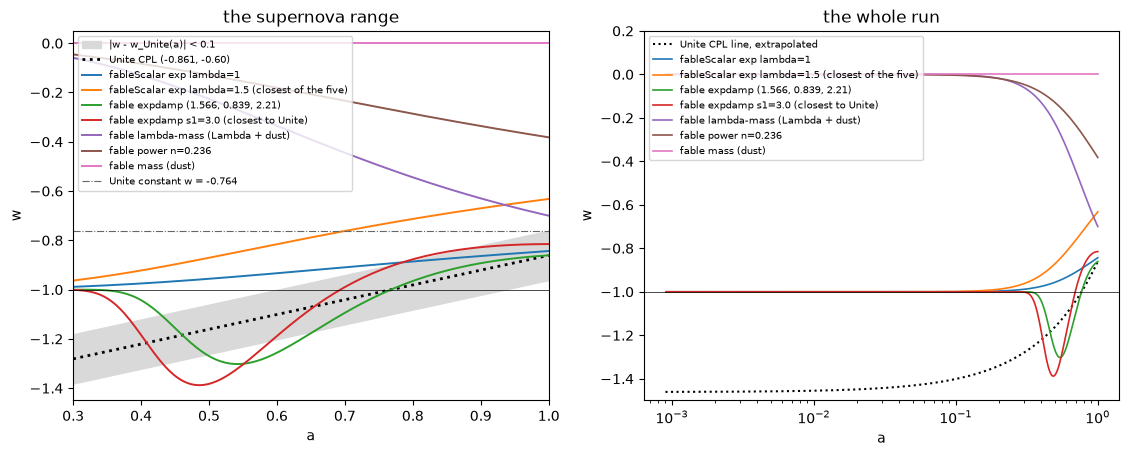

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.5, 4.8))
au = np.linspace(0.3, 1.0, 200)
ax1.fill_between(au, UNITE_W0 + UNITE_WA * (1 - au) - 0.1, UNITE_W0 + UNITE_WA * (1 - au) + 0.1, color='0.85', label='|w - w_Unite(a)| < 0.1')
ax1.plot(au, UNITE_W0 + UNITE_WA * (1 - au), 'k:', lw=2, label='Unite CPL (-0.861, -0.60)')
afull = np.geomspace(9e-4, 1.0, 300)
ax2.plot(afull, UNITE_W0 + UNITE_WA * (1 - afull), 'k:', lw=1.5, label='Unite CPL line, extrapolated')
for key, model, args, label, wcol, ocol in BEST:
    d = RUNS[key]['table']
    line, = ax1.plot(d['a'], d[wcol], lw=1.4, label=label)
    ax2.plot(d['a'], d[wcol], lw=1.2, color=line.get_color(), label=label)
ax1.axhline(UNITE_WCONST, color='0.4', lw=0.8, ls='-.', label='Unite constant w = -0.764')
for ax in (ax1, ax2):
    ax.axhline(-1, color='k', lw=0.5); ax.set_xlabel('a'); ax.set_ylabel('w')
ax1.set_xlim(0.3, 1); ax1.set_ylim(-1.45, 0.05); ax1.set_title('the supernova range'); ax1.legend(fontsize=7, loc='upper left')
ax2.set_xscale('log'); ax2.set_ylim(-1.5, 0.2); ax2.set_title('the whole run'); ax2.legend(fontsize=7, loc='upper left')
fig.savefig(RESULTS / 'nb04_w_of_a_all.png', dpi=130, bbox_inches='tight'); print('figure: results/nb04_w_of_a_all.png'); plt.show()

### 5.4 Figure (ii): the density fractions `Ω_field(a)`, `Ω_m(a)`, `Ω_r(a)`

For the reference `expdamp` spinor and the `λ = 1` exponential scalar: matter (radiation is
already the minor component at the start, `N0 = −7`, since with `Ω_r0 = 8.4e−5` equality was at
`a_eq = Ω_r0/Ω_m0 = 2.8e−4`), then the field, which reaches `Ω = 0.6999` today by construction.
The moment the field overtakes matter is marked and printed.  `results/nb04_omega_history.png`.

radiation-matter equality, analytic: a_eq = Omega_r0/Omega_m0 = 2.80e-04 (z = 3570), before the runs start (a = 9.12e-04)
fable expdamp (1.566, 0.839, 2.21)     Omega_r(N0) = 0.2349;  the field overtakes matter at a = 0.7376 (z = 0.356);  Omega_field(1) = 0.699905
fableScalar exp lambda=1               Omega_r(N0) = 0.2349;  the field overtakes matter at a = 0.7239 (z = 0.381);  Omega_field(1) = 0.699916
figure: results/nb04_omega_history.png


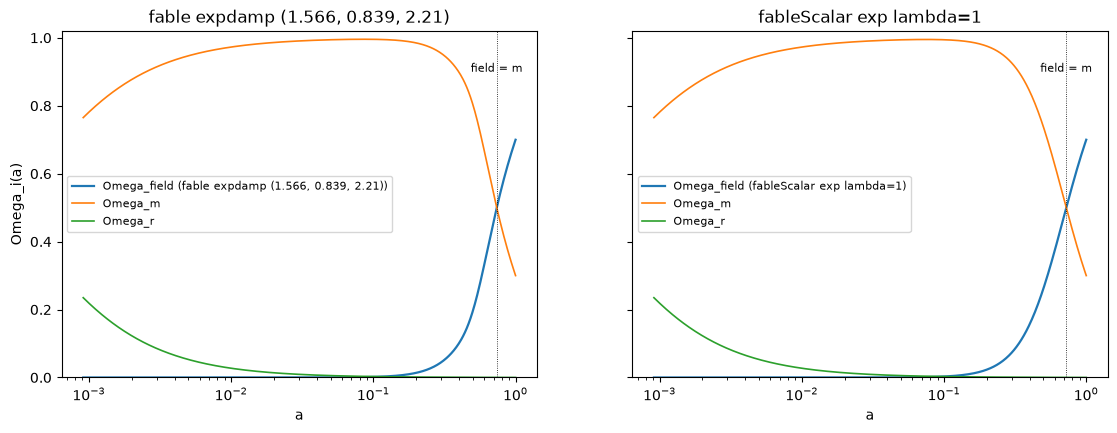

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.5), sharey=True)
print(f'radiation-matter equality, analytic: a_eq = Omega_r0/Omega_m0 = {OR / OM:.2e} (z = {OM / OR - 1:.0f}), before the runs start (a = {np.exp(-7.0):.2e})')
for ax, key in zip(axes, ['nb04_expdamp_ref', 'nb04_exp_lambda1']):
    d = RUNS[key]['table']; oc = RUNS[key]['ocol']
    ax.plot(d['a'], d[oc], lw=1.6, label=f'Omega_field ({RUNS[key]["label"]})')
    ax.plot(d['a'], d['Omega_m'], lw=1.2, label='Omega_m'); ax.plot(d['a'], d['Omega_r'], lw=1.2, label='Omega_r')
    ax.set_xscale('log'); ax.set_xlabel('a'); ax.set_title(RUNS[key]['label']); ax.legend(fontsize=8, loc='center left'); ax.set_ylim(0, 1.02)
    i_dom = int(np.where(d[oc] > d['Omega_m'])[0][0])
    a_dom = float(np.exp(np.interp(0.0, (d[oc] - d['Omega_m'])[i_dom - 5:i_dom + 5], d['N'][i_dom - 5:i_dom + 5])))
    ax.axvline(a_dom, color='k', lw=0.6, ls=':'); ax.annotate('field = m', (a_dom, 0.9), fontsize=8, ha='center')
    print(f'{RUNS[key]["label"]:38s} Omega_r(N0) = {d["Omega_r"][0]:.4f};  the field overtakes matter at a = {a_dom:.4f} (z = {1 / a_dom - 1:.3f});  Omega_field(1) = {d[oc][-1]:.6f}')
axes[0].set_ylabel('Omega_i(a)')
fig.savefig(RESULTS / 'nb04_omega_history.png', dpi=130, bbox_inches='tight'); print('figure: results/nb04_omega_history.png'); plt.show()

### 5.5 Figure (iii): the deceleration parameter `q_dec(a) = −1 − (dH/dN)/H`

`q_dec = +1` in the radiation era, `+½` in the matter era, negative once the field accelerates
the expansion; the scale factor of the onset of acceleration (`q_dec = 0`) is printed for both
cases.  The phantom dip of `expdamp` shows as a deeper minimum of `q_dec`.
`results/nb04_deceleration.png`.

fable expdamp (1.566, 0.839, 2.21)     acceleration begins (q_dec = 0) at a = 0.5475 (z = 0.827);  q_dec(1) = -0.4037
fableScalar exp lambda=1               acceleration begins (q_dec = 0) at a = 0.5840 (z = 0.712);  q_dec(1) = -0.3854
fable lambda-mass (Lambda + dust)      acceleration begins (q_dec = 0) at a = 0.8045 (z = 0.243);  q_dec(1) = -0.2349
fable mass (dust)                      never accelerates;  q_dec(1) = +0.5000
figure: results/nb04_deceleration.png


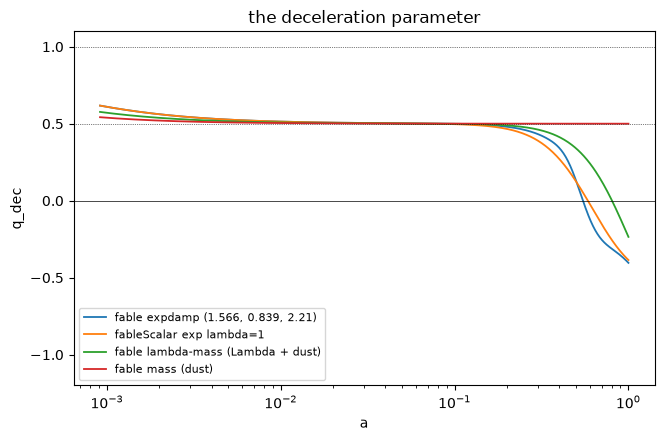

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.6))
for key in ['nb04_expdamp_ref', 'nb04_exp_lambda1', 'nb04_lambda-mass', 'nb04_mass']:
    d = RUNS[key]['table']
    ax.plot(d['a'], d['q_dec'], lw=1.3, label=RUNS[key]['label'])
    m = d['a'] >= 0.2
    if (d['q_dec'][m] < 0).any():
        a_acc = float(np.exp(np.interp(0.0, -d['q_dec'][m], d['N'][m])))
        print(f'{RUNS[key]["label"]:38s} acceleration begins (q_dec = 0) at a = {a_acc:.4f} (z = {1 / a_acc - 1:.3f});  q_dec(1) = {d["q_dec"][-1]:+.4f}')
    else:
        print(f'{RUNS[key]["label"]:38s} never accelerates;  q_dec(1) = {d["q_dec"][-1]:+.4f}')
ax.axhline(0, color='k', lw=0.5); ax.axhline(0.5, color='k', lw=0.5, ls=':'); ax.axhline(1.0, color='k', lw=0.5, ls=':')
ax.set_xscale('log'); ax.set_xlabel('a'); ax.set_ylabel('q_dec'); ax.set_ylim(-1.2, 1.1); ax.legend(fontsize=8); ax.set_title('the deceleration parameter')
fig.savefig(RESULTS / 'nb04_deceleration.png', dpi=130, bbox_inches='tight'); print('figure: results/nb04_deceleration.png'); plt.show()

## 6. This notebook's results

Everything this notebook writes lives under `results/`:

- `results/nb04_exp_lambda1.csv`, `results/nb04_exp_lambda1.5.csv`, `results/nb04_expdamp_ref.csv`,
  `results/nb04_expdamp_s3.csv`, `results/nb04_lambda-mass.csv`, `results/nb04_power_n0.236.csv`, `results/nb04_mass.csv`
  — the re-runs of 5.1;
- `results/nb04_w_of_a_all.png`, `results/nb04_omega_history.png`, `results/nb04_deceleration.png` — the three figures of the paper.

It reads `results/nb01_cpl_fits.csv` and `results/nb02_cpl_fits.csv`, written by the two FLRW
notebooks.  The cell below reads one of its own CSVs back with Python's `csv` module alone
(no numpy, no solver) and prints today's row, as anyone can.

In [7]:
import csv
with open(RESULTS / 'nb04_expdamp_ref.csv', newline='') as f:
    rows = list(csv.DictReader(f))
print(f'{len(rows)} rows, columns: {", ".join(rows[0].keys())}')
for r in [rows[0], rows[len(rows) // 2], rows[-1]]:
    print(f"a = {float(r['a']):.6f}  z = {float(r['z']):10.3f}  t = {float(r['t']):.6f}  s = {float(r['s']):.4e}  w_Psi = {float(r['w_Psi']):+.6f}  Omega_Psi = {float(r['Omega_Psi']):.6f}  q_dec = {float(r['q_dec']):+.4f}")

701 rows, columns: a, z, N, t, s, H, K_Psi, U_Psi, rho_Psi, P_Psi, w_Psi, Omega_Psi, Omega_m, Omega_r, q_dec
a = 0.000912  z =   1095.633  t = 0.000022  s = 1.3188e+09  w_Psi = -1.000000  Omega_Psi = 0.000000  q_dec = +0.6175
a = 0.030197  z =     32.115  t = 0.006305  s = 3.6316e+04  w_Psi = -1.000000  Omega_Psi = 0.000047  q_dec = +0.5045
a = 1.000000  z =      0.000  t = 0.964336  s = 1.0000e+00  w_Psi = -0.860846  Omega_Psi = 0.699905  q_dec = -0.4037


## 7. The questions, answered

**Is there a connection to dark matter?  Yes, three of them, one of them exact.**
(1) The spinor's mass term — the author's own `V = −(2M/H) s`, the Lagrangian of the original
model promoted to a cosmological field — is **dust, exactly**: `w_Ψ = s V′/V − 1 = 0`
identically, and the `mass` run gives `w = 0` at all 701 points to `1e−14`, with
`ρ_Ψ = V(s) ∝ a^{−3}` (the `s = s0 a^{−3}` dilution law of the reference model).  A 16-component
spinor of `Spin(4,4)` with a mass term is cold dark matter.  (2) The scalar oscillating in a
quadratic potential on the pre-universe, with no Hubble friction, has the virial average
`⟨w⟩ = 0`: measured `w_avg(x4 = 100) = +0.0044` (Model C), and in the reference model an
oscillating `quadratic` field dilutes as dust once it oscillates.  (3) The `power` spinor with
`n = 0.236` is dust early (`w(a = 0.1) = −0.004`) and only later turns into dark energy.

**Is there a connection to dark energy?  Yes, by two different mechanisms, with these numbers.**
*fableScalar* rolling under Hubble friction (Model A) is standard thawing quintessence:
`exp λ = 1` gives `w(1) = −0.843`, CPL fit `(w0, wa) = (−0.844, −0.217)`; `λ = 1.5` gives
`(−0.618, −0.502)`, the closest of the values run to Unite's `(−0.861, −0.60)` (distance 0.263);
`λ ≈ 1.64` reaches `wa = −0.60` with `w0 ≈ −0.53`.  It has Unite's sign pattern (`w0 > −1`,
`wa < 0`) and a CPL extrapolation `w0 + wa` below −1 (−1.06 for `λ = 1`, −1.12 for `λ = 1.5`)
while its true `w` never drops below −1 (`min w = −1.000000`, the null energy condition): it
cannot give a genuine phantom past.  *fable* with a potential whose slope changes sign
(Model B) does: the reference `expdamp` `(1.566, 0.839, 2.21)` has `w(1) = −0.861`, crosses
`w = −1` at `a = 0.768` (`z = 0.30`), reaches `w = −1.302` at `z = 0.84` and fits
`(−0.978, −0.245)`; `expdamp` with `s1 = 3.0` fits `(−0.851, −0.569)`, `w0 + wa = −1.42`, the
closest of every run in both notebooks to Unite's `(−0.861, −0.60, −1.46)`, with a genuine
`w < −1` in the past and `ρ_Ψ = V > 0` throughout — the classical spinor-quintom mechanism,
with no wrong-sign kinetic term.  Two more spinor cases are dark energy of a different kind:
`lambda-mass` reaches `w(1) = −0.700`, but its `Ω_Λ = V(0)/3 = 0.490` is a bare cosmological
constant in the action (ΛCDM with spinor dust, `Ω = 0.210`, not field-driven dark energy), and
`power n = 0.236` is field-driven (`w → n − 1 = −0.764`, Unite's constant-w value, exactly at
late times: `w(a = e⁶) + 0.764 = 8e−7`) but has `w(1) = −0.382` with `m = λ`.

**What is the framework's own mechanism?**  On the pre-universe itself — not in the reference
models — the frame does two things.  There is **no Hubble friction** along the observer's time
(`Sqrt[g] g^{44} = −Sec[6Hx0]` is `x4`-independent, because the observed sheet's expansion is
compensated by the second sheet's contraction), so fableScalar oscillates undamped with
`ρ` conserved (drift `3e−9`) and virial-averaged `w` (0 for the mass term, 1/3 for the quartic),
and fable's bilinear does not dilute at all, `ds/dx4 = 0` exactly (Model E): its `w = sV′/V − 1`
is fixed once and for all.  And a field with a profile along the hidden coordinate `x0` stores
energy in the `x0` gradient, which on the observed sheet is a `w = −1` component (`ρ = G0`,
`P = −G0`) while along `x0` itself it is an anisotropic stress (`P_0 = +G0`); with a potential the
store sloshes into the `x4` motion and back (Model D: up to 97.8 % of the energy in the gradient,
`w_sheet` swinging between −1 and +0.80, the discrete energy conserved to `1e−8`).  A
time-varying `w` on the pre-universe therefore comes from oscillation and sloshing, not from
rolling; the average of a massive field is dust, and only a massless profile stays at `w = −1`.

**What is NOT established.**  (1) The framework has **no gravitational sector**: no Einstein
equations, `a4` undetermined, so nothing here says which density gravitates or what `a(t)` is;
every `H(a)`, every `Ω`, every CPL fit above belongs to the 4-dimensional reference models,
obtained by holding the hidden volume fixed and letting the field source a Friedmann equation
on a separate FLRW frame.  (2) **Perturbations are not examined**: the spinor's crossing of the
phantom divide is a statement about the homogeneous background; the stability of perturbations
in that phase — the known weak point of quintom models — has not been studied.  (3) **The
volume bookkeeping caveat**: integrating the 8-dimensional action over the hidden coordinates
multiplies every density by the hidden 4-volume density `𝒱_hid ∝ a^{−3}`, so the reduced
`ρ_4 ∝ a^{−3} ρ_8` is not separately conserved and dilutes like dust for *every* `w` — a
cosmological constant would pass the same test; it is a volume effect, not a dark-matter
signature, and the locally measured `T_{44} = ρ_8` is exactly constant.  Whether `ρ_4` or `ρ_8`
is the gravitating density is undetermined without a gravitational sector.  (4) The kinematic
identification `ln a = −a4[Ht]` with `a4′ < 0` is a hypothesis about the sign, not a result.

The cell below re-derives every number quoted in this section from the tables and the re-runs
and fails if the text has gone stale.

In [8]:
g = lambda run, col: float(T[run][col])
assert np.abs(RUNS['nb04_mass']['table']['w_Psi']).max() <= 1e-14
assert abs(g('exp lambda=1', 'w_a1') + 0.843) < 1e-3 and abs(g('exp lambda=1', 'w0_fit') + 0.844) < 1e-3 and abs(g('exp lambda=1', 'wa_fit') + 0.217) < 1e-3
assert abs(g('exp lambda=1.5', 'w0_fit') + 0.618) < 1e-3 and abs(g('exp lambda=1.5', 'wa_fit') + 0.502) < 1e-3 and abs(g('exp lambda=1.5', 'dist_to_unite') - 0.263) < 1e-3
assert abs(g('exp lambda=1', 'w0_plus_wa') + 1.06) < 5e-3 and abs(g('exp lambda=1.5', 'w0_plus_wa') + 1.12) < 5e-3
assert all(abs(g(r['run'], 'w_min') + 1.0) < 1e-6 for r in merged if r['model'] == 'scalar-flrw')
E = 'expdamp (1.566, 0.839, 2.21) reference'
d = RUNS['nb04_expdamp_ref']['table']
assert abs(g(E, 'w_a1') + 0.861) < 1e-3 and abs(g(E, 'w_min') + 1.302) < 1e-3 and abs(g(E, 'w0_fit') + 0.978) < 1e-3 and abs(g(E, 'wa_fit') + 0.245) < 1e-3
assert abs(crossings(d['N'], d['w_Psi'])[0] - 0.768) < 1e-3 and abs(d['z'][d['w_Psi'].argmin()] - 0.84) < 5e-3
assert merged[0]['run'] == 'expdamp s1=3.0' and abs(g('expdamp s1=3.0', 'w0_fit') + 0.851) < 1e-3 and abs(g('expdamp s1=3.0', 'wa_fit') + 0.569) < 1e-3 and abs(g('expdamp s1=3.0', 'w0_plus_wa') + 1.42) < 5e-3
assert abs(g('lambda-mass v0=0.7 m=0.3', 'w_a1') + 0.700) < 1e-3 and abs(RUNS['nb04_lambda-mass']['params']['v0'] / 3 - 0.490) < 1e-3 and abs(RUNS['nb04_lambda-mass']['params']['m'] / 3 - 0.210) < 1e-3
P = RUNS['nb04_power_n0.236']['table']
assert abs(P['w_Psi'][-1] + 0.382) < 1e-3 and abs(w_at(P['a'], P['w_Psi'], 0.1) + 0.004) < 1e-3
scan = np.genfromtxt(RESULTS / 'nb01_lambda_scan.csv', delimiter=',', names=True)
assert abs(np.interp(-0.60, scan['wa_fit'][::-1], scan['lambda'][::-1]) - 1.64) < 0.01
print('every number quoted in section 7 agrees with the tables and the runs')

every number quoted in section 7 agrees with the tables and the runs


## 8. Name this notebook and save it

The last two cells are the interactive ones.  The first asks you for a name for this notebook
(press Enter to keep the current one); the second opens the usual graphical *Save as* dialog so
you can put a copy of the notebook -- with all the outputs you have just produced -- wherever you
like.  When the notebook is executed headlessly (by `run_all.sh`, `run_all.ps1` or `nbconvert`)
there is nobody to answer, so both cells detect that and print a one-line notice instead.

In [9]:
import os, sys

def headless_now():
    """True when nobody can answer a prompt: nbconvert / nbclient execution (the kernel's stdin is
    disabled), a FABLE_HEADLESS environment variable, or a plain Python run without a terminal."""
    if os.environ.get('FABLE_HEADLESS'):
        return True
    try:
        return not get_ipython().kernel._allow_stdin
    except Exception:
        return not sys.stdin.isatty()

HEADLESS = headless_now()
if HEADLESS:
    NOTEBOOK_NAME = '04_dark_matter_dark_energy'
    print('Headless execution: no prompt; the notebook keeps its name', NOTEBOOK_NAME)
else:
    NOTEBOOK_NAME = input('Name for this notebook: ').strip() or '04_dark_matter_dark_energy'
    print('This notebook is called', NOTEBOOK_NAME)

Headless execution: no prompt; the notebook keeps its name 04_dark_matter_dark_energy


If the graphical dialog cannot be opened (no display, or Tk missing from your Python), the cell
falls back to asking for a folder path in plain text and copies the notebook there.

In [10]:
import shutil
from pathlib import Path

if globals().get('HEADLESS', True):
    print('Headless execution: the save dialog is skipped; the notebook stays where it is.')
else:
    target = ''
    try:
        import tkinter
        from tkinter import filedialog
        root = tkinter.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        target = filedialog.asksaveasfilename(title='Save a copy of this notebook as',
                                              initialfile=NOTEBOOK_NAME + '.ipynb', defaultextension='.ipynb',
                                              filetypes=[('Jupyter notebook', '*.ipynb'), ('All files', '*.*')])
        root.destroy()
    except Exception as exc:
        print(f'No graphical dialog is available ({exc}). Falling back to a typed folder path.')
        folder = input('Folder to save a copy of this notebook into (empty = do not save): ').strip()
        if folder:
            target = str(Path(folder) / (NOTEBOOK_NAME + '.ipynb'))
    if target:
        shutil.copyfile(Path.cwd() / '04_dark_matter_dark_energy.ipynb', target)
        print('A copy of this notebook was saved as', target)
    else:
        print('Nothing saved.')

Headless execution: the save dialog is skipped; the notebook stays where it is.
